In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/superstore_cleaned.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (9977, 18)
Columns: ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Unit_Price', 'Profit_Margin', 'Revenue', 'Discount_Band', 'Price_Segment']


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Unit_Price,Profit_Margin,Revenue,Discount_Band,Price_Segment
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,130.9800,16.00,261.9600,No Discount,Premium
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,243.9800,30.00,731.9400,No Discount,Premium
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,7.3100,47.00,14.6200,No Discount,Premium
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,191.5155,-40.00,957.5775,High (41%+),Premium
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.1840,11.25,22.3680,Low (1-20%),Low


In [2]:
print("Categories")
print(df['Category'].value_counts())

print("\nSub-Categories")
print(df['Sub-Category'].value_counts())

print("\nDiscount Band Distribution")
print(df['Discount_Band'].value_counts())

print("\nPrice Segment Distribution")
print(df['Price_Segment'].value_counts())

Categories
Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

Sub-Categories
Sub-Category
Binders        1522
Paper          1359
Furnishings     956
Phones          889
Storage         846
Art             795
Accessories     775
Chairs          615
Appliances      466
Labels          363
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

Discount Band Distribution
Discount_Band
No Discount        4787
Low (1-20%)        3799
High (41%+)         932
Medium (21-40%)     459
Name: count, dtype: int64

Price Segment Distribution
Price_Segment
Low        3353
Mid        3328
Premium    3296
Name: count, dtype: int64


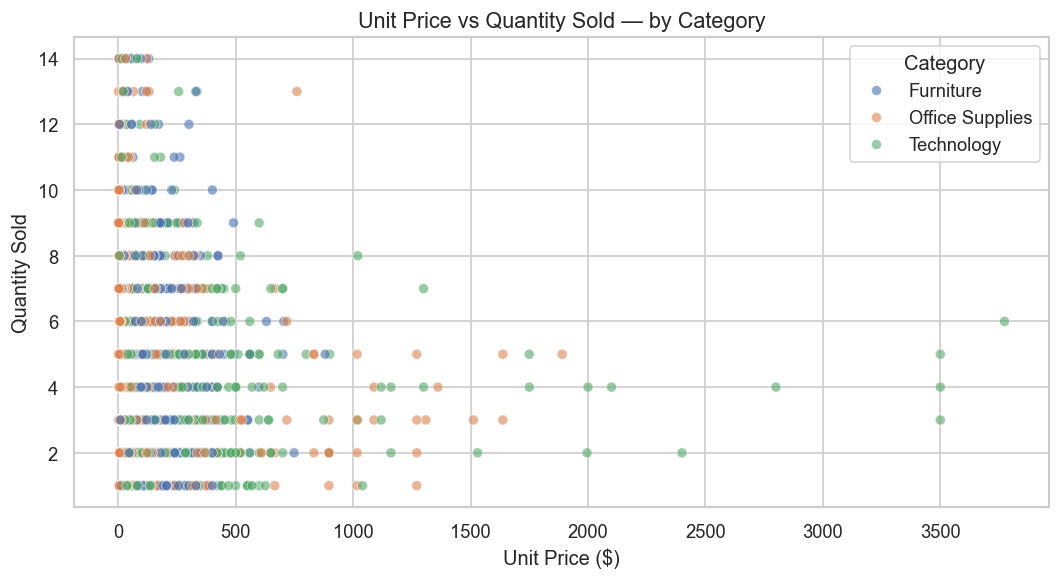

In [3]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Unit_Price', y='Quantity', hue='Category', alpha=0.6)
plt.title("Unit Price vs Quantity Sold — by Category", fontsize=13)
plt.xlabel("Unit Price ($)")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.savefig('../outputs/01_price_vs_quantity.png')
plt.show()

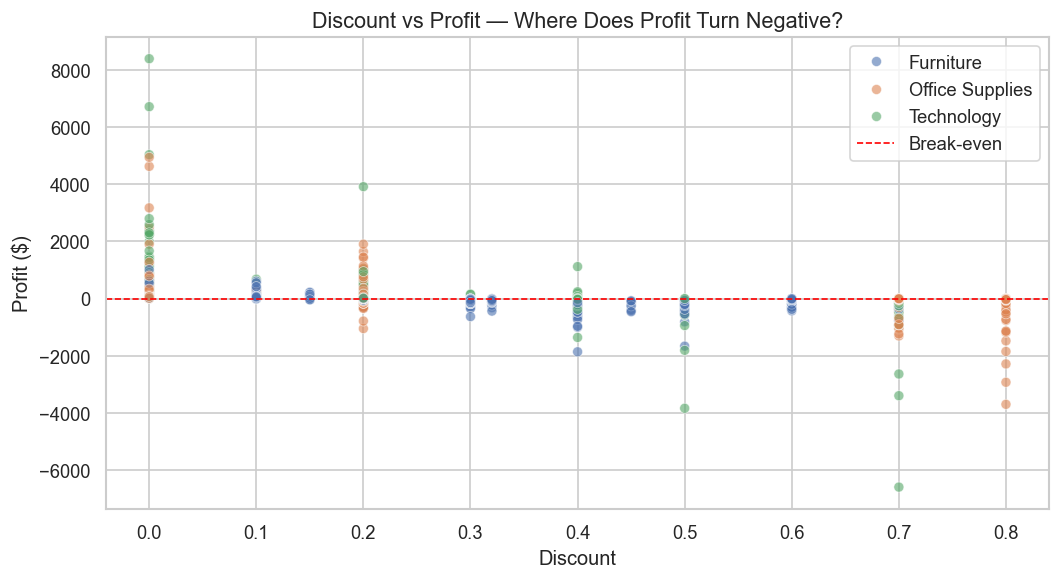

In [4]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
plt.title("Discount vs Profit — Where Does Profit Turn Negative?", fontsize=13)
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/02_discount_vs_profit.png')
plt.show()

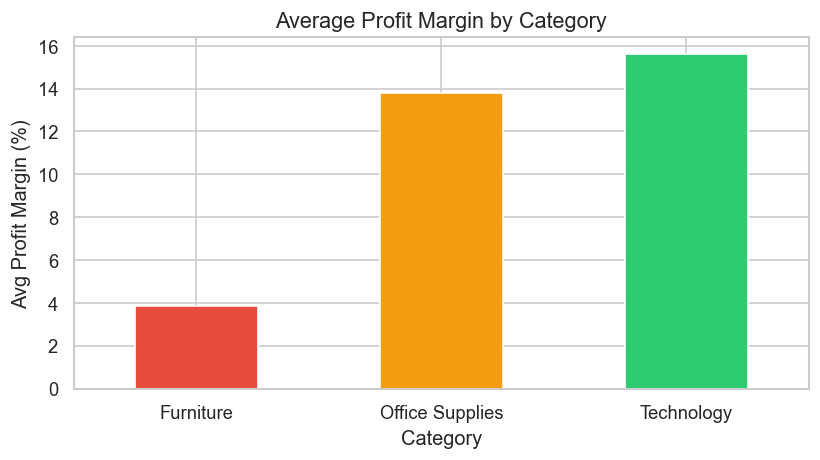

Category
Furniture           3.867929
Office Supplies    13.773504
Technology         15.613805
Name: Profit_Margin, dtype: float64


In [5]:
cat_margin = df.groupby('Category')['Profit_Margin'].mean().sort_values()

plt.figure(figsize=(7, 4))
cat_margin.plot(kind='bar', color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title("Average Profit Margin by Category", fontsize=13)
plt.xlabel("Category")
plt.ylabel("Avg Profit Margin (%)")
plt.xticks(rotation=0)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/03_profit_margin_by_category.png')
plt.show()

print(cat_margin)

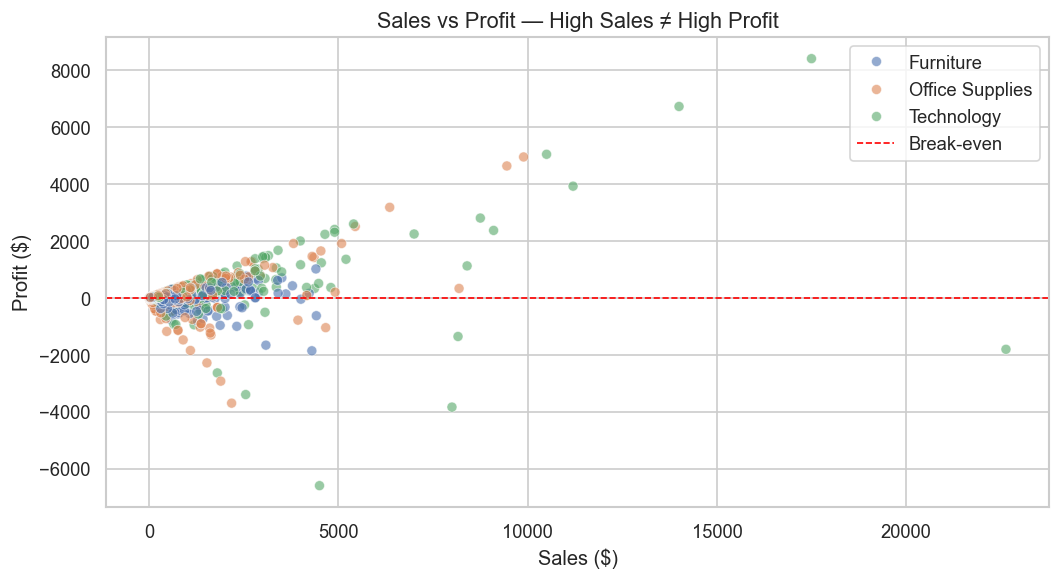

In [6]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
plt.title("Sales vs Profit — High Sales ≠ High Profit", fontsize=13)
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/04_sales_vs_profit.png')
plt.show()

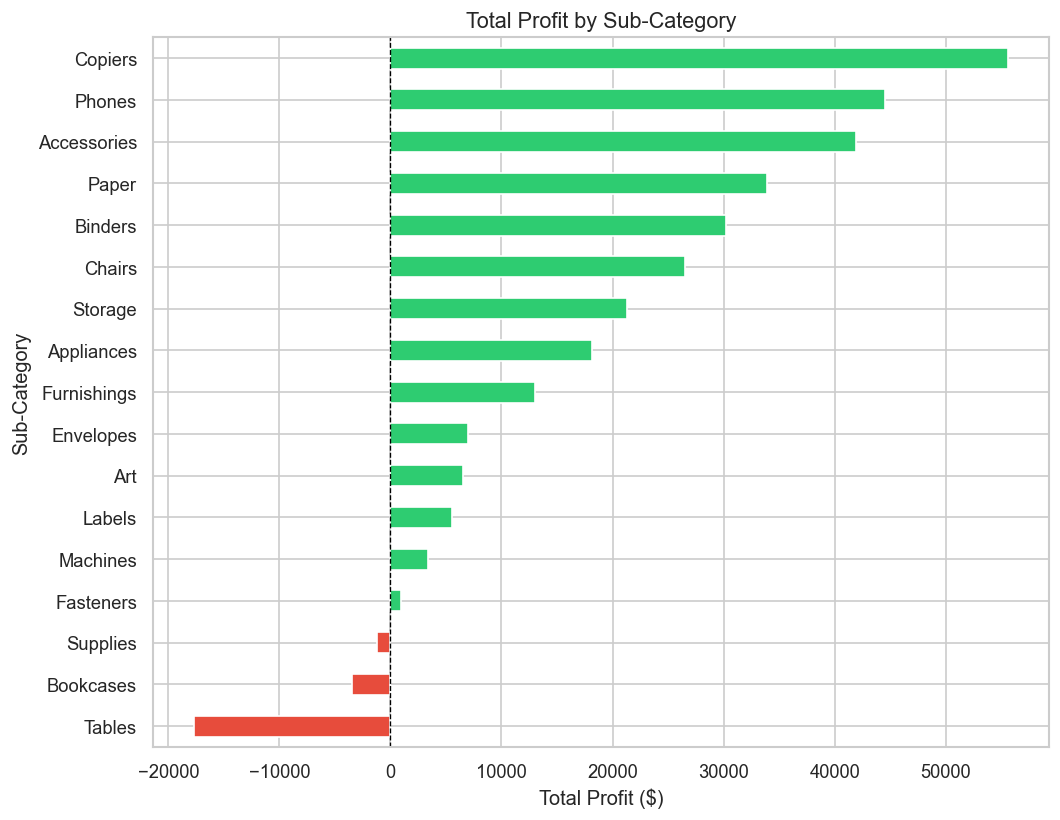

Loss-making Sub-Categories:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


In [7]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(9, 7))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sub_profit]
sub_profit.plot(kind='barh', color=colors)
plt.title("Total Profit by Sub-Category", fontsize=13)
plt.xlabel("Total Profit ($)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/05_profit_by_subcategory.png')
plt.show()

print("Loss-making Sub-Categories:")
print(sub_profit[sub_profit < 0])

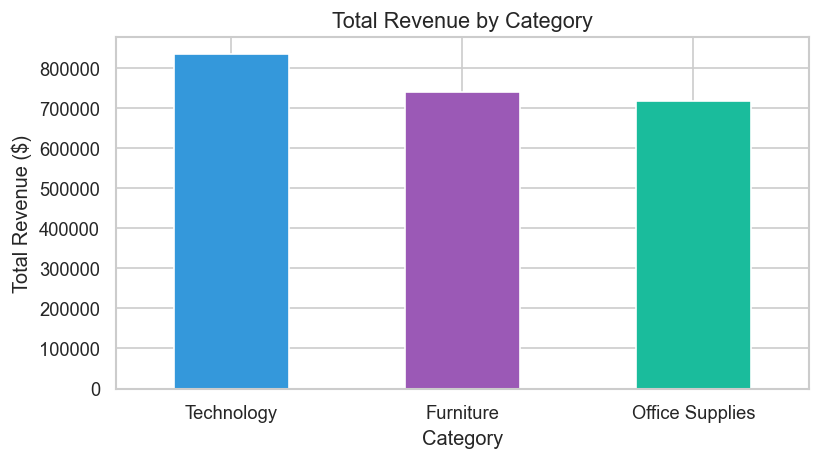

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Revenue, dtype: float64


In [8]:
cat_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
cat_revenue.plot(kind='bar', color=['#3498db', '#9b59b6', '#1abc9c'])
plt.title("Total Revenue by Category", fontsize=13)
plt.xlabel("Category")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/06_revenue_by_category.png')
plt.show()

print(cat_revenue)

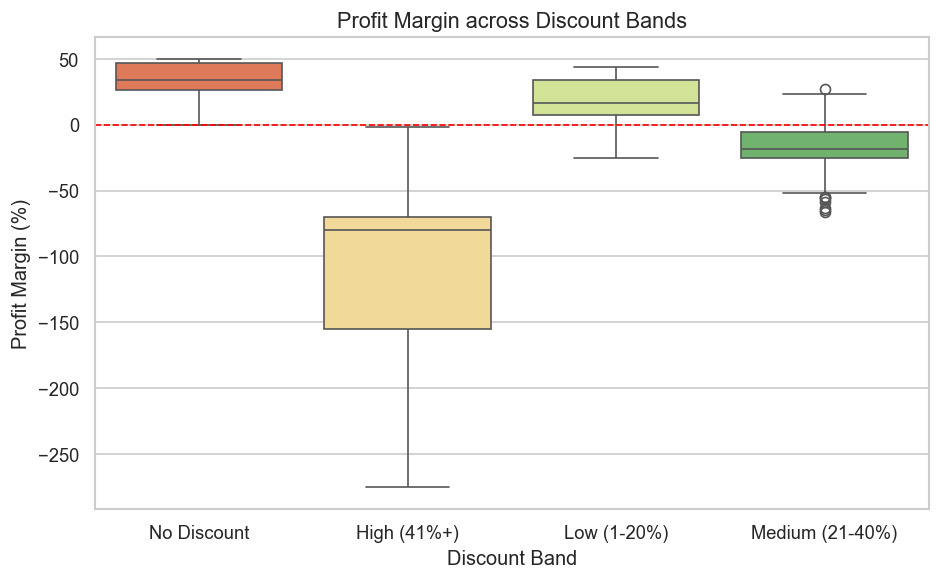

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Discount_Band', y='Profit_Margin', palette='RdYlGn')
plt.title("Profit Margin across Discount Bands", fontsize=13)
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../outputs/07_discountband_vs_margin.png')
plt.show()

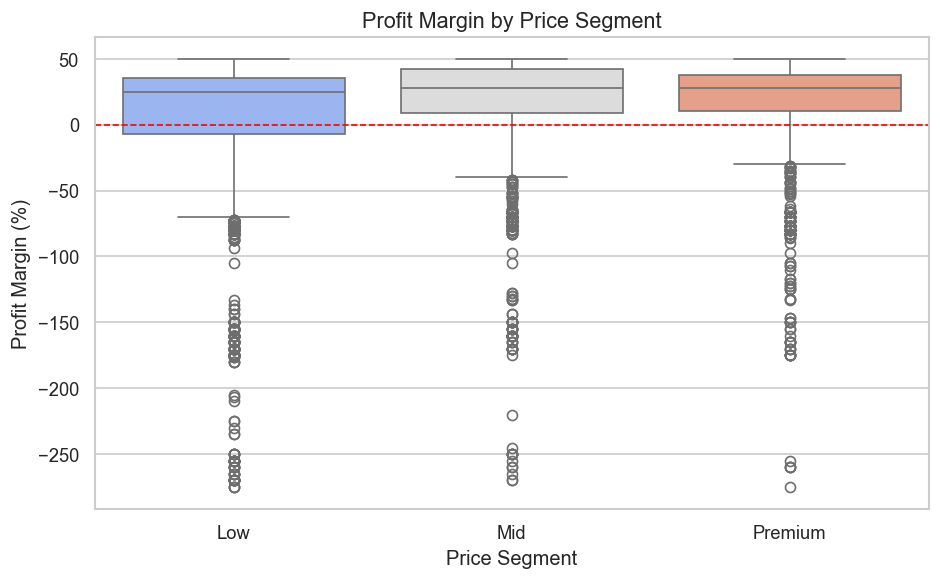

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Price_Segment', y='Profit_Margin', palette='coolwarm',
            order=['Low', 'Mid', 'Premium'])
plt.title("Profit Margin by Price Segment", fontsize=13)
plt.xlabel("Price Segment")
plt.ylabel("Profit Margin (%)")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../outputs/08_pricesegment_vs_margin.png')
plt.show()

In [11]:
agg = df.groupby('Category').agg(
    Avg_Unit_Price=('Unit_Price', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Profit_Margin=('Profit_Margin', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum')
).round(2)

print("=== Category Aggregation Summary ===")
print(agg)

=== Category Aggregation Summary ===
                 Avg_Unit_Price  Avg_Quantity  Avg_Profit_Margin  \
Category                                                           
Furniture                 90.85          3.79               3.87   
Office Supplies           32.21          3.80              13.77   
Technology               120.39          3.76              15.61   

                 Total_Revenue  Total_Profit  
Category                                      
Furniture            741306.31      18421.81  
Office Supplies      718735.24     122364.66  
Technology           836154.03     145454.95  


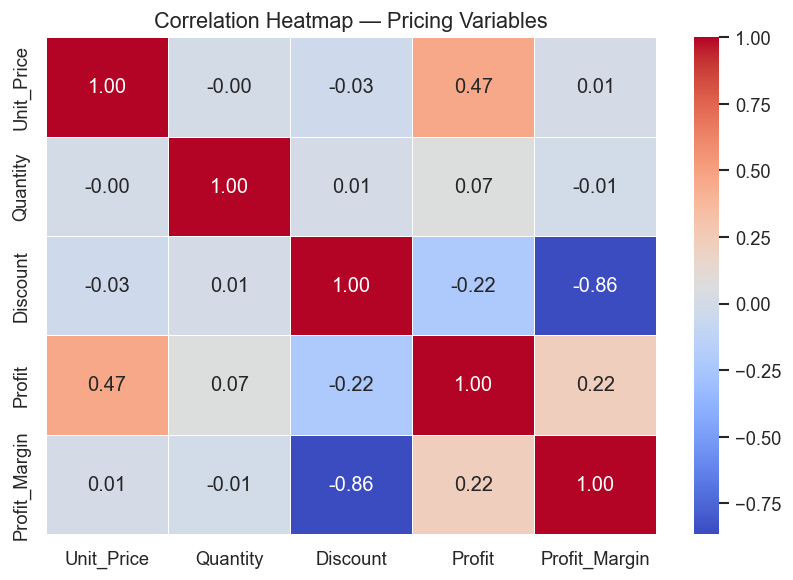

In [12]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['Unit_Price', 'Quantity', 'Discount', 'Profit', 'Profit_Margin']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Heatmap — Pricing Variables", fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/09_correlation_heatmap.png')
plt.show()

In [14]:
discount_summary = df.groupby('Discount_Band')['Profit_Margin'].mean().round(2)

print("Avg Profit Margin by Discount Band")
print(discount_summary)
print()

for band, margin in discount_summary.items():
    status = "Profitable" if margin > 0 else "Loss-making"
    print(f"{band:25} → {margin:6.2f}%   {status}")

Avg Profit Margin by Discount Band
Discount_Band
High (41%+)       -108.83
Low (1-20%)         17.42
Medium (21-40%)    -16.71
No Discount         34.00
Name: Profit_Margin, dtype: float64

High (41%+)               → -108.83%   Loss-making
Low (1-20%)               →  17.42%   Profitable
Medium (21-40%)           → -16.71%   Loss-making
No Discount               →  34.00%   Profitable


In [16]:
print("EDA SUMMARY — KEY INSIGHTS")


print(f"\n1. Revenue by Category:")
print(df.groupby('Category')['Revenue'].sum().round(2))

print(f"\n2. Avg Profit Margin by Category:")
print(df.groupby('Category')['Profit_Margin'].mean().round(2))

print(f"\n3. Loss-making Sub-Categories:")
loss = df.groupby('Sub-Category')['Profit'].sum()
print(loss[loss < 0].round(2))

print(f"\n4. Avg Profit Margin by Discount Band:")
print(df.groupby('Discount_Band')['Profit_Margin'].mean().round(2))

print(f"\n5. Negative Profit Transactions: {len(df[df['Profit'] < 0])}")
print(f"   That's {round(len(df[df['Profit'] < 0])/len(df)*100, 2)}% of all transactions")

EDA SUMMARY — KEY INSIGHTS

1. Revenue by Category:
Category
Furniture          741306.31
Office Supplies    718735.24
Technology         836154.03
Name: Revenue, dtype: float64

2. Avg Profit Margin by Category:
Category
Furniture           3.87
Office Supplies    13.77
Technology         15.61
Name: Profit_Margin, dtype: float64

3. Loss-making Sub-Categories:
Sub-Category
Bookcases    -3472.56
Supplies     -1189.10
Tables      -17725.48
Name: Profit, dtype: float64

4. Avg Profit Margin by Discount Band:
Discount_Band
High (41%+)       -108.83
Low (1-20%)         17.42
Medium (21-40%)    -16.71
No Discount         34.00
Name: Profit_Margin, dtype: float64

5. Negative Profit Transactions: 1869
   That's 18.73% of all transactions


EDA Conclusions — Key Business Insights

1. Revenue vs Profit Imbalance
Technology generates the highest revenue ($836K) with strong profit margins (~15.6%).
Furniture generates comparable revenue ($741K) but has extremely low margins (~3.9%),
indicating inefficient pricing or excessive discounting.

Business Implication: Revenue alone is misleading — Furniture looks strong on sales
but is actually weak on profitability.

2. Category-Level Pricing Behavior
- Office Supplies → high-volume, low-price strategy → stable margins (~13.8%)
- Technology → premium pricing strategy → highest margins (~15.6%)
- Furniture → fails to achieve either → moderate revenue, weak margins (~3.9%)

Business Implication: Each category requires a different pricing strategy.
A one-size-fits-all approach will not work.

3. Structural Loss-Making Products
Tables (-$17,725), Bookcases (-$3,472), and Supplies (-$1,189) are consistently loss-making.

Business Implication:These are not random losses — these are systematic pricing failures.

Recommended Actions:
- Reduce discounts on these sub-categories
- Increase base price
- Or bundle strategically with high-margin products


4. Discounting is Destroying Profit
| Discount Band  | Avg Profit Margin |
|----------------|-------------------|
| No Discount    | +34.00%           |
| Low (1-20%)    | +17.42%           |
| Medium (21-40%)| -16.71%           |
| High (41%+)    | -108.83%          |

Profit margin drops from +34% (No Discount) to -108.8% (High Discount).

Strong Statement:
> "Aggressive discounting (>40%) leads to catastrophic profit losses and should be
> strictly avoided across all categories."

5. High Rate of Loss-Making Transactions
1,869 out of 9,977 transactions (~18.7%) are unprofitable.
Nearly 1 in 5 sales is destroying business value.

Business Implication: This is not a minor inefficiency — it is a systemic pricing problem.

Final EDA Conclusion
The analysis reveals that pricing inefficiencies are widespread across the dataset.
While Technology maintains healthy margins, Furniture suffers from aggressive discounting
and structurally unprofitable products. A significant portion of transactions (~19%)
results in negative profit, indicating that current pricing strategies prioritize sales
volume over profitability.

These findings highlight the need for category-specific pricing strategies and motivate
a deeper analysis using demand response and elasticity in the next step.